In [2]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Dell\OneDrive\Desktop\spotter-freight-rate-ml\.venv312\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Notebook environment OK")
print("Python:", __import__("sys").version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", __import__("matplotlib").__version__)

Notebook environment OK
Python: 3.12.10
Pandas: 2.3.3
NumPy: 2.5.3
Matplotlib: 3.11.2


In [4]:
# Load assessment datasets

train = pd.read_csv("../data/train-test.csv")
validation = pd.read_csv("../data/validation.csv")
december = pd.read_csv("../data/december-chart-inputs.csv")

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("December shape:", december.shape)

Train shape: (48000, 14)
Validation shape: (12000, 13)
December shape: (31, 7)


In [5]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [11]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


In [14]:
print("TRAIN COLUMNS")
print(train.columns.tolist())

print("\nVALIDATION COLUMNS")
print(validation.columns.tolist())

print("\nDECEMBER COLUMNS")
print(december.columns.tolist())

TRAIN COLUMNS
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']

VALIDATION COLUMNS
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal']

DECEMBER COLUMNS
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [16]:
# ==========================================
# STEP 3: DATA QUALITY AUDIT
# ==========================================

print("=== MISSING VALUES ===")
print(train.isna().sum())

=== MISSING VALUES ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64


In [18]:
print("=== DUPLICATES ===")

print("Duplicate rows:", train.duplicated().sum())
print("Duplicate load_ids:", train["load_id"].duplicated().sum())

=== DUPLICATES ===
Duplicate rows: 0
Duplicate load_ids: 0


In [20]:
print("=== UNIQUE VALUES ===")

for col in ["pickup", "delivery", "equipment"]:
    print(f"\n{col}:")
    print("Train unique:", train[col].nunique())
    print("Validation unique:", validation[col].nunique())

=== UNIQUE VALUES ===

pickup:
Train unique: 64
Validation unique: 72

delivery:
Train unique: 64
Validation unique: 72

equipment:
Train unique: 3
Validation unique: 3


In [7]:
# Convert a temporary copy only for inspection
train_dates = pd.to_datetime(train["date"], errors="coerce")
validation_dates = pd.to_datetime(validation["date"], errors="coerce")

print("=== DATE QUALITY ===")

print("Invalid train dates:", train_dates.isna().sum())
print("Invalid validation dates:", validation_dates.isna().sum())

print("\nTrain date range:")
print(train_dates.min(), "to", train_dates.max())

print("\nValidation date range:")
print(validation_dates.min(), "to", validation_dates.max())

print("\nTrain unique dates:", train_dates.nunique())
print("Validation unique dates:", validation_dates.nunique())

=== DATE QUALITY ===
Invalid train dates: 0
Invalid validation dates: 0

Train date range:
2025-01-01 00:00:00 to 2025-10-31 00:00:00

Validation date range:
2025-11-01 00:00:00 to 2025-12-31 00:00:00

Train unique dates: 304
Validation unique dates: 61


In [24]:
print("=== WEIGHT INVESTIGATION ===")

print("Negative weights:", (train["weight"] < 0).sum())
print("Zero weights:", (train["weight"] == 0).sum())
print("Positive weights:", (train["weight"] > 0).sum())

print("\nSmallest weights:")
print(train["weight"].nsmallest(20).tolist())

print("\nLargest weights:")
print(train["weight"].nlargest(20).tolist())

=== WEIGHT INVESTIGATION ===
Negative weights: 292
Zero weights: 0
Positive weights: 47408

Smallest weights:
[-47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -47500.0, -46334.0, -46187.0, -45975.0, -45588.0, -45221.0, -45128.0, -44754.0]

Largest weights:
[47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0, 47500.0]


In [25]:
print("=== WEIGHT VALUE DISTRIBUTION ===")
print(train["weight"].value_counts(dropna=False).head(30))

=== WEIGHT VALUE DISTRIBUTION ===
weight
 47500.0    1191
 NaN         300
 5000.0       31
-47500.0      13
 32436.0      10
 32153.0      10
 28444.0       9
 27028.0       9
 28876.0       9
 34863.0       9
 26564.0       9
 31460.0       9
 28436.0       8
 32724.0       8
 31630.0       8
 35657.0       8
 36569.0       8
 31787.0       8
 31157.0       8
 33775.0       8
 28318.0       8
 30517.0       8
 34925.0       8
 37858.0       8
 29262.0       8
 32825.0       8
 28815.0       8
 30795.0       8
 34355.0       8
 24175.0       8
Name: count, dtype: int64


In [8]:
print("=== EQUIPMENT ===")
print(train["equipment"].value_counts(dropna=False))

print("\n=== TOP PICKUP LOCATIONS ===")
print(train["pickup"].value_counts().head(15))

print("\n=== TOP DELIVERY LOCATIONS ===")
print(train["delivery"].value_counts().head(15))

=== EQUIPMENT ===
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

=== TOP PICKUP LOCATIONS ===
pickup
Oklahoma City    1242
Lexington        1209
Bakersfield      1193
Fort Wayne       1170
Hartford         1150
Richmond         1140
Nashville        1124
Phoenix          1121
Baton Rouge      1115
Mobile           1094
Cincinnati       1080
Shreveport       1062
Kansas City      1053
Columbia         1049
Atlanta          1029
Name: count, dtype: int64

=== TOP DELIVERY LOCATIONS ===
delivery
Lexington        1197
Fort Wayne       1176
Baton Rouge      1167
Bakersfield      1156
Hartford         1143
Oklahoma City    1140
Richmond         1109
Atlanta          1096
Phoenix          1090
Mobile           1089
Cincinnati       1084
Columbia         1071
Nashville        1064
Tucson            997
Shreveport        983
Name: count, dtype: int64


In [10]:
train_pickups = set(train["pickup"].dropna().unique())
val_pickups = set(validation["pickup"].dropna().unique())

train_deliveries = set(train["delivery"].dropna().unique())
val_deliveries = set(validation["delivery"].dropna().unique())

unseen_pickups = sorted(val_pickups - train_pickups)
unseen_deliveries = sorted(val_deliveries - train_deliveries)

print("=== UNSEEN CITIES IN VALIDATION ===")

print("Unseen pickup cities:", len(unseen_pickups))
print(unseen_pickups)

print("\nUnseen delivery cities:", len(unseen_deliveries))
print(unseen_deliveries)

=== UNSEEN CITIES IN VALIDATION ===
Unseen pickup cities: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']

Unseen delivery cities: 8
['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']


In [11]:
unseen_pickup_rows = validation["pickup"].isin(unseen_pickups).sum()
unseen_delivery_rows = validation["delivery"].isin(unseen_deliveries).sum()

print("Validation rows with unseen pickup:", unseen_pickup_rows)
print("Validation rows with unseen delivery:", unseen_delivery_rows)

Validation rows with unseen pickup: 725
Validation rows with unseen delivery: 722


In [31]:
print("=== TARGET QUALITY ===")

print("Missing:", train["posted_rate"].isna().sum())
print("Zero:", (train["posted_rate"] == 0).sum())
print("Negative:", (train["posted_rate"] < 0).sum())

print("\nLowest rates:")
print(train["posted_rate"].nsmallest(10).tolist())

print("\nHighest rates:")
print(train["posted_rate"].nlargest(10).tolist())

=== TARGET QUALITY ===
Missing: 0
Zero: 0
Negative: 0

Lowest rates:
[57.22, 59.68, 63.36, 67.8, 75.19, 76.54, 82.38, 94.72, 101.63, 103.15]

Highest rates:
[25533.0, 24294.98, 24140.21, 23662.71, 23580.42, 22755.66, 22534.65, 20361.89, 20132.37, 19110.3]


In [34]:
print("=== MISSING VALUES: TRAIN vs VALIDATION ===")

missing_comparison = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "validation_missing": validation.isna().sum()
})

print(missing_comparison)

=== MISSING VALUES: TRAIN vs VALIDATION ===
              train_missing  validation_missing
date                      0                 0.0
delivery                  0                 0.0
delivery_lat              0                 0.0
delivery_lon              0                 0.0
distance                  0                 0.0
equipment                 0                 0.0
load_id                   0                 0.0
market_index            374               249.0
pickup                    0                 0.0
pickup_lat                0                 0.0
pickup_lon                0                 0.0
posted_rate               0                 NaN
quote_signal              0                 0.0
weight                  300               165.0


In [35]:
print("=== NEGATIVE WEIGHT ANALYSIS ===")

negative_weight = train[train["weight"] < 0].copy()

print("Negative-weight rows:", len(negative_weight))

print("\nNegative weight statistics:")
print(negative_weight["weight"].describe())

print("\nNegative weights by equipment:")
print(negative_weight["equipment"].value_counts())

print("\nNegative weights by date:")
print(negative_weight["date"].value_counts().head(15))

print("\nNegative weight vs target:")
print(
    negative_weight[["weight", "distance", "market_index", "quote_signal", "posted_rate"]]
    .describe()
)

=== NEGATIVE WEIGHT ANALYSIS ===
Negative-weight rows: 292

Negative weight statistics:
count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64

Negative weights by equipment:
equipment
Dry Van    155
Flatbed     70
Reefer      67
Name: count, dtype: int64

Negative weights by date:
date
2025-03-08    4
2025-01-02    3
2025-01-11    3
2025-01-12    3
2025-02-02    3
2025-03-18    3
2025-03-19    3
2025-03-09    3
2025-02-25    3
2025-03-07    3
2025-02-15    3
2025-02-09    3
2025-03-17    3
2025-03-22    3
2025-10-25    3
Name: count, dtype: int64

Negative weight vs target:
             weight     distance  market_index  quote_signal   posted_rate
count    292.000000   292.000000    289.000000    292.000000    292.000000
mean  -31724.195205  1120.920205      1.096322      2.041966   2389.786233
std     8262.536326   733.132047      0.171

In [36]:
print("=== EXTREME WEIGHTS ===")

print("\nMost negative:")
print(
    train.nsmallest(15, "weight")[
        ["pickup", "delivery", "distance", "equipment", "weight", "date", "posted_rate"]
    ]
)

print("\nMost positive:")
print(
    train.nlargest(15, "weight")[
        ["pickup", "delivery", "distance", "equipment", "weight", "date", "posted_rate"]
    ]
)


=== EXTREME WEIGHTS ===

Most negative:
              pickup       delivery  distance equipment   weight        date  \
5034     San Antonio         Tucson    1053.5   Dry Van -47500.0  2025-02-01   
5236   Oklahoma City    Baton Rouge     459.1    Reefer -47500.0  2025-02-02   
12591    Los Angeles       Richmond    2749.0    Reefer -47500.0  2025-03-21   
13620     Fort Wayne   Philadelphia     789.2   Dry Van -47500.0  2025-03-28   
16823        Madison      Green Bay     273.1   Dry Van -47500.0  2025-04-16   
18064      Green Bay    Kansas City     475.4   Flatbed -47500.0  2025-04-24   
18488       Syracuse        Phoenix    2760.8   Flatbed -47500.0  2025-04-27   
20576     Montgomery       Amarillo    1265.6   Flatbed -47500.0  2025-05-10   
22422       Amarillo  San Francisco    1185.8   Dry Van -47500.0  2025-05-22   
26026     Charleston    Baton Rouge     934.9   Dry Van -47500.0  2025-06-13   
26106   Philadelphia    Baton Rouge    1452.6   Dry Van -47500.0  2025-06-14   


In [12]:
unseen_either = (
    validation["pickup"].isin(unseen_pickups)
    | validation["delivery"].isin(unseen_deliveries)
)

unseen_both = (
    validation["pickup"].isin(unseen_pickups)
    & validation["delivery"].isin(unseen_deliveries)
)

print("=== UNSEEN LOCATION IMPACT ===")
print("Rows with unseen pickup OR delivery:", unseen_either.sum())
print("Rows with unseen pickup AND delivery:", unseen_both.sum())
print("Percentage of validation:", round(unseen_either.mean() * 100, 2), "%")

=== UNSEEN LOCATION IMPACT ===
Rows with unseen pickup OR delivery: 1447
Rows with unseen pickup AND delivery: 0
Percentage of validation: 12.06 %


In [38]:
print("=== VALIDATION QUALITY ===")

print("Missing values:")
print(validation.isna().sum())

print("\nNegative weights:", (validation["weight"] < 0).sum())
print("Zero weights:", (validation["weight"] == 0).sum())

print("\nEquipment:")
print(validation["equipment"].value_counts(dropna=False))

=== VALIDATION QUALITY ===
Missing values:
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          165
date              0
market_index    249
quote_signal      0
dtype: int64

Negative weights: 145
Zero weights: 0

Equipment:
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169
Name: count, dtype: int64


In [13]:
# ==========================================
# STEP 3.6: NEGATIVE WEIGHT IMPACT
# ==========================================

negative = train[train["weight"] < 0]
positive = train[train["weight"] > 0]
missing = train[train["weight"].isna()]

comparison = pd.DataFrame({
    "Negative weight": negative["posted_rate"].describe(),
    "Positive weight": positive["posted_rate"].describe(),
    "Missing weight": missing["posted_rate"].describe()
})

comparison

,Negative weight,Positive weight,Missing weight
count,292.000000,47408.000000,300.000000
mean,2389.786233,2374.030869,2350.665767
std,1641.761285,1486.103110,1390.972806
min,247.370000,57.220000,148.720000
25%,1257.410000,1251.712500,1229.660000
50%,1994.960000,2031.440000,1984.995000
75%,3185.257500,3330.790000,3397.890000
max,14561.210000,25533.000000,6546.690000


In [10]:
print("=== TARGET COMPARISON ===")

print("Negative weight mean:",
      round(negative["posted_rate"].mean(), 2))

print("Positive weight mean:",
      round(positive["posted_rate"].mean(), 2))

print("Missing weight mean:",
      round(missing["posted_rate"].mean(), 2))

print("\nNegative weight median:",
      round(negative["posted_rate"].median(), 2))

print("Positive weight median:",
      round(positive["posted_rate"].median(), 2))

print("Missing weight median:",
      round(missing["posted_rate"].median(), 2))

=== TARGET COMPARISON ===
Negative weight mean: 2389.79
Positive weight mean: 2374.03
Missing weight mean: 2350.67

Negative weight median: 1994.96
Positive weight median: 2031.44
Missing weight median: 1985.0


In [12]:
print("=== WEIGHT / RATE CORRELATION ===")

print(
    train[["weight", "posted_rate"]]
    .corr()
    )

=== WEIGHT / RATE CORRELATION ===
              weight  posted_rate
weight       1.00000      0.03484
posted_rate  0.03484      1.00000


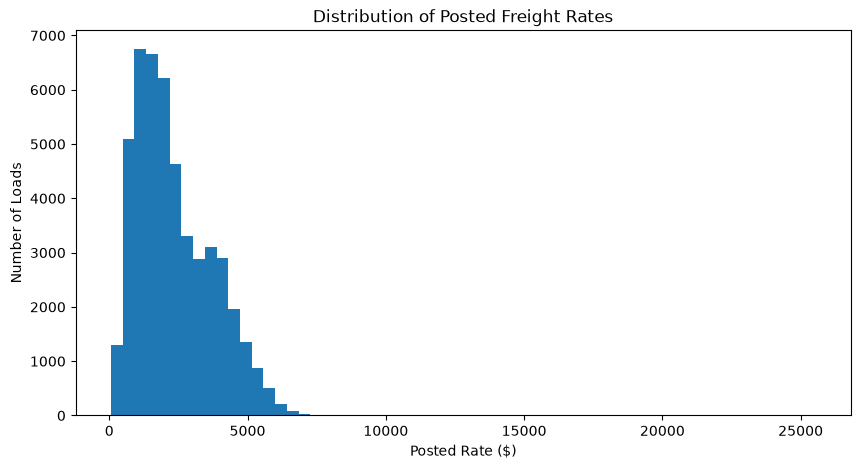

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(train["posted_rate"], bins=60)

plt.title("Distribution of Posted Freight Rates")
plt.xlabel("Posted Rate ($)")
plt.ylabel("Number of Loads")

plt.show()

In [ ]:
print(train["posted_rate"].skew())


1.9023948792201801


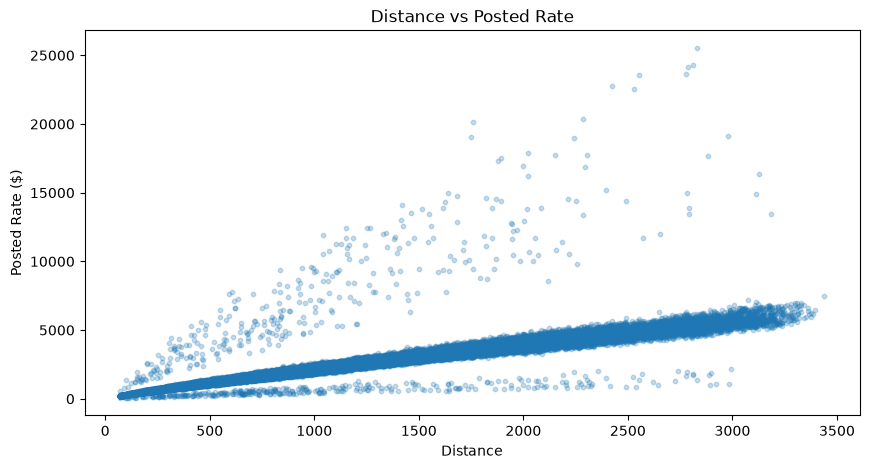

In [17]:
plt.figure(figsize=(10, 5))

plt.scatter(
    train["distance"],
    train["posted_rate"],
    alpha=0.25,
    s=10
)

plt.title("Distance vs Posted Rate")
plt.xlabel("Distance")
plt.ylabel("Posted Rate ($)")

plt.show()

In [18]:
print(train["posted_rate"].skew())

1.9023948792201801


In [15]:
numeric_cols = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

correlation = train[numeric_cols].corr()["posted_rate"].sort_values(
    ascending=False
)

print(correlation)

posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086
Name: posted_rate, dtype: float64


In [16]:
equipment_summary = (
    train.groupby("equipment")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

equipment_summary

,count,mean,median,std
equipment,,,,
Reefer,12045,2553.636939,2196.670,1589.670824
Flatbed,8753,2445.087223,2076.810,1505.053087
Dry Van,27202,2271.548686,1953.035,1423.029914


In [17]:
eda = train.copy()

eda["rate_per_mile"] = eda["posted_rate"] / eda["distance"]

eda["date_dt"] = pd.to_datetime(eda["date"])

eda["month"] = eda["date_dt"].dt.month
eda["day_of_week"] = eda["date_dt"].dt.dayofweek

eda[["posted_rate", "distance", "rate_per_mile"]].describe()

,posted_rate,distance,rate_per_mile
count,48000.000000,48000.000000,48000.000000
mean,2373.980682,1135.856654,2.215347
std,1486.493245,728.564416,0.583887
min,57.220000,70.000000,0.333709
25%,1251.555000,550.400000,1.986974
50%,2030.760000,953.300000,2.145348
75%,3330.750000,1645.525000,2.342696
max,25533.000000,3439.800000,14.125294


In [18]:
print("Rate per mile quantiles:")
print(
    eda["rate_per_mile"]
    .quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
)


Rate per mile quantiles:
0.00     0.333709
0.01     1.673521
0.05     1.807533
0.25     1.986974
0.50     2.145348
0.75     2.342696
0.95     2.735925
0.99     3.176940
1.00    14.125294
Name: rate_per_mile, dtype: float64


In [19]:
rate_mile_equipment = (
    eda.groupby("equipment")["rate_per_mile"]
    .agg(["count", "mean", "median", "std"])
)

rate_mile_equipment

,count,mean,median,std
equipment,,,,
Dry Van,27202,2.115401,2.046203,0.538102
Flatbed,8753,2.294729,2.219683,0.610187
Reefer,12045,2.383376,2.311540,0.615467


In [30]:
monthly_summary = (
    eda.groupby("month")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
)

monthly_summary

,count,mean,median,std
month,,,,
1,4918,2255.967048,1915.200,1454.274952
2,4337,2273.804801,1994.250,1317.077105
3,5036,2372.268092,2022.920,1462.531615
4,4819,2372.162308,2044.240,1463.102457
5,4913,2421.776342,2065.510,1486.071436
6,4783,2497.030115,2120.220,1606.707302
7,4912,2415.162030,2059.145,1504.943296
8,4759,2338.407661,2015.730,1474.979672
9,4670,2406.374013,2057.130,1523.483983


In [31]:
monthly_rate_per_mile = (
    eda.groupby("month")["rate_per_mile"]
    .agg(["mean", "median"])
)

monthly_rate_per_mile

,mean,median
month,,
1,2.100221,2.029158
2,2.122885,2.061143
3,2.206132,2.139279
4,2.210309,2.146699
5,2.260106,2.190194
6,2.332484,2.247885
7,2.255952,2.187422
8,2.188584,2.120525
9,2.229725,2.159622


In [32]:
monthly_rate_per_mile = (
    eda.groupby("month")["rate_per_mile"]
    .agg(["mean", "median"])
)

monthly_rate_per_mile

,mean,median
month,,
1,2.100221,2.029158
2,2.122885,2.061143
3,2.206132,2.139279
4,2.210309,2.146699
5,2.260106,2.190194
6,2.332484,2.247885
7,2.255952,2.187422
8,2.188584,2.120525
9,2.229725,2.159622


In [33]:
eda["route"] = eda["pickup"] + " → " + eda["delivery"]

route_summary = (
    eda.groupby("route")["posted_rate"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)

route_summary.head(20)

,count,mean,median,std
route,,,,
Columbia → Oklahoma City,39,2330.734615,2327.430,172.229178
Phoenix → Shreveport,39,3507.618462,3554.430,242.204457
Lexington → Atlanta,39,560.106154,553.630,50.720487
Fort Wayne → Philadelphia,38,1681.032632,1708.835,256.611701
Shreveport → Hartford,37,2867.768108,2812.520,194.815806
Fort Wayne → Hartford,37,1938.657297,1725.990,864.431736
Richmond → Oklahoma City,37,3093.435946,3126.490,451.844903
Richmond → Phoenix,37,5190.194595,5010.880,1301.128774
Lexington → Kansas City,37,1042.474595,1029.800,67.641548


In [34]:
print("Unique routes:", eda["route"].nunique())

Unique routes: 4014


In [22]:
train_routes = set(
    train["pickup"] + " → " + train["delivery"]
)

validation_routes = validation["pickup"] + " → " + validation["delivery"]

unseen_route_mask = ~validation_routes.isin(train_routes)

print("Validation rows:", len(validation))
print("Unseen routes:", unseen_route_mask.sum())
print(
    "Unseen route percentage:",
    round(unseen_route_mask.mean() * 100, 2),
    "%"
)

Validation rows: 12000
Unseen routes: 1461
Unseen route percentage: 12.18 %


In [21]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))


eda["geo_distance"] = haversine_miles(
    eda["pickup_lat"],
    eda["pickup_lon"],
    eda["delivery_lat"],
    eda["delivery_lon"]
)

eda[["distance", "geo_distance"]].describe()

,distance,geo_distance
count,48000.000000,48000.000000
mean,1135.856654,966.154360
std,728.564416,630.650711
min,70.000000,7.265240
25%,550.400000,456.537929
50%,953.300000,806.935637
75%,1645.525000,1410.670791
max,3439.800000,2873.652583


In [23]:
print(
    eda[["distance", "geo_distance"]].corr()
)

              distance  geo_distance
distance      1.000000      0.999535
geo_distance  0.999535      1.000000


In [25]:
print("=== RATE PER MILE CORRELATIONS ===")

rpm_cols = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon"
]

print(
    eda[rpm_cols + ["rate_per_mile"]]
    .corr()["rate_per_mile"]
    .sort_values(ascending=False)
)

=== RATE PER MILE CORRELATIONS ===
rate_per_mile    1.000000
market_index     0.083478
weight           0.074517
pickup_lon       0.054985
delivery_lon     0.054667
quote_signal     0.049342
delivery_lat    -0.030460
pickup_lat      -0.032631
distance        -0.334601
Name: rate_per_mile, dtype: float64


In [26]:
dow_rpm = (
    eda.groupby("day_of_week")["rate_per_mile"]
    .agg(["mean", "median"])
)

dow_rpm.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_rpm

,mean,median
Monday,2.196373,2.126141
Tuesday,2.213440,2.139350
Wednesday,2.248383,2.163024
Thursday,2.244592,2.170587
Friday,2.214910,2.157178
Saturday,2.195747,2.131724
Sunday,2.192251,2.127364


In [27]:
# ==========================================
# STEP 5: TIME-BASED VALIDATION
# ==========================================

model_data = train.copy()

model_data["date_dt"] = pd.to_datetime(model_data["date"])

train_mask = model_data["date_dt"] < "2025-10-01"
valid_mask = model_data["date_dt"] >= "2025-10-01"

dev_train = model_data.loc[train_mask].copy()
dev_valid = model_data.loc[valid_mask].copy()

print("Development training:", dev_train.shape)
print("Development validation:", dev_valid.shape)

print("\nTraining date range:")
print(dev_train["date_dt"].min(), "to", dev_train["date_dt"].max())

print("\nValidation date range:")
print(dev_valid["date_dt"].min(), "to", dev_valid["date_dt"].max())

Development training: (43147, 15)
Development validation: (4853, 15)

Training date range:
2025-01-01 00:00:00 to 2025-09-30 00:00:00

Validation date range:
2025-10-01 00:00:00 to 2025-10-31 00:00:00


In [28]:
print("Training target mean:",
      round(dev_train["posted_rate"].mean(), 2))

print("Validation target mean:",
      round(dev_valid["posted_rate"].mean(), 2))

print("\nTraining months:",
      sorted(dev_train["date_dt"].dt.month.unique()))

print("Validation months:",
      sorted(dev_valid["date_dt"].dt.month.unique()))

Training target mean: 2373.41
Validation target mean: 2379.05

Training months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9)]
Validation months: [np.int32(10)]


In [29]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon"
]

X_train = dev_train[baseline_features]
y_train = dev_train["posted_rate"]

X_valid = dev_valid[baseline_features]
y_valid = dev_valid["posted_rate"]

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_valid_imp = imputer.transform(X_valid)

print("Training matrix:", X_train_imp.shape)
print("Validation matrix:", X_valid_imp.shape)

Training matrix: (43147, 8)
Validation matrix: (4853, 8)


In [31]:
baseline_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

baseline_model.fit(X_train_imp, y_train)

baseline_pred = baseline_model.predict(X_valid_imp)

In [32]:
baseline_mae = mean_absolute_error(y_valid, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_valid, baseline_pred))

print("Baseline MAE :", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))

Baseline MAE : 178.94
Baseline RMSE: 668.01


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon"
]

categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

X_train_cat = dev_train[numeric_features + categorical_features]
X_valid_cat = dev_valid[numeric_features + categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train_cat)
X_valid_processed = preprocessor.transform(X_valid_cat)

print("Training matrix:", X_train_processed.shape)
print("Validation matrix:", X_valid_processed.shape)

Training matrix: (43147, 139)
Validation matrix: (4853, 139)


In [34]:
categorical_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

categorical_model.fit(
    X_train_processed,
    y_train
)

categorical_pred = categorical_model.predict(X_valid_processed)

In [35]:
categorical_mae = mean_absolute_error(
    y_valid,
    categorical_pred
)

categorical_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        categorical_pred
    )
)

print("Categorical Model MAE :", round(categorical_mae, 2))
print("Categorical Model RMSE:", round(categorical_rmse, 2))

Categorical Model MAE : 129.18
Categorical Model RMSE: 654.62


In [36]:
error_analysis = dev_valid[
    [
        "load_id",
        "pickup",
        "delivery",
        "equipment",
        "distance",
        "weight",
        "market_index",
        "quote_signal",
        "date",
        "posted_rate"
    ]
].copy()

error_analysis["prediction"] = categorical_pred

error_analysis["error"] = (
    error_analysis["posted_rate"]
    - error_analysis["prediction"]
)

error_analysis["abs_error"] = (
    error_analysis["error"].abs()
)

error_analysis["squared_error"] = (
    error_analysis["error"] ** 2
)

error_analysis = error_analysis.sort_values(
    "abs_error",
    ascending=False
)

error_analysis.head(20)

,load_id,pickup,delivery,equipment,distance,weight,market_index,quote_signal,date,posted_rate,prediction,error,abs_error,squared_error
43539,TR-043540,Milwaukee,Bakersfield,Dry Van,1893.0,30760.0,1.08079,2.22972,2025-10-03,17514.11,3656.214048,13857.895952,13857.895952,1.920413e+08
46213,TR-046214,Columbia,Tucson,Flatbed,2023.4,34710.0,0.89822,2.06797,2025-10-20,17893.17,4176.409976,13716.760024,13716.760024,1.881495e+08
47298,TR-047299,Boston,Bakersfield,Reefer,2979.1,30585.0,0.86501,2.09472,2025-10-27,19110.30,5887.210931,13223.089069,13223.089069,1.748501e+08
46516,TR-046517,Toledo,Albuquerque,Reefer,1684.3,31536.0,0.98632,2.05917,2025-10-22,14784.38,3548.050301,11236.329699,11236.329699,1.262551e+08
47536,TR-047537,Los Angeles,Richmond,Dry Van,2782.4,25730.0,1.03410,2.39203,2025-10-29,15003.55,4916.647509,10086.902491,10086.902491,1.017456e+08
46366,TR-046367,Bakersfield,Columbia,Dry Van,2251.9,40729.0,0.94743,2.19163,2025-10-21,14403.14,4325.972721,10077.167279,10077.167279,1.015493e+08
44267,TR-044268,Albany,Albuquerque,Dry Van,2492.6,25513.0,1.05590,2.38846,2025-10-08,14425.42,4349.448082,10075.971918,10075.971918,1.015252e+08
43302,TR-043303,Atlanta,Phoenix,Reefer,2083.1,40335.0,0.90740,1.94613,2025-10-01,13894.55,4476.148077,9418.401923,9418.401923,8.870629e+07
43384,TR-043385,Lexington,Lubbock,Dry Van,1187.0,25359.0,0.95849,2.17408,2025-10-02,11696.44,2340.778624,9355.661376,9355.661376,8.752840e+07
47586,TR-047587,Corpus Christi,Las Vegas,Flatbed,1383.3,18645.0,1.01713,2.02448,2025-10-29,11596.28,2827.857948,8768.422052,8768.422052,7.688523e+07


In [38]:
print("=== ERROR DISTRIBUTION ===")

print(
    error_analysis["abs_error"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

=== ERROR DISTRIBUTION ===
count     4853.000000
mean       129.179563
std        641.815069
min          0.026997
50%         46.147172
75%         89.661273
90%        169.635160
95%        262.272894
99%       1785.922520
max      13857.895952
Name: abs_error, dtype: float64


In [39]:
print("\nErrors above thresholds:")

for threshold in [250, 500, 1000, 2000, 5000]:
    count = (error_analysis["abs_error"] > threshold).sum()
    pct = count / len(error_analysis) * 100

    print(
        f">{threshold:>4}: {count:4} rows "
        f"({pct:.2f}%)"
    )


Errors above thresholds:
> 250:  257 rows (5.30%)
> 500:   95 rows (1.96%)
>1000:   66 rows (1.36%)
>2000:   46 rows (0.95%)
>5000:   21 rows (0.43%)


In [40]:
train_routes = set(
    dev_train["pickup"] + " → " + dev_train["delivery"]
)

error_analysis["route"] = (
    error_analysis["pickup"]
    + " → "
    + error_analysis["delivery"]
)

error_analysis["unseen_route"] = (
    ~error_analysis["route"].isin(train_routes)
)

print(
    error_analysis.groupby("unseen_route")["abs_error"]
    .agg(["count", "mean", "median"])
)

              count        mean     median
unseen_route                              
False          4845  129.261699  46.147172
True              8   79.436124  48.704832


In [41]:
print(
    error_analysis.groupby("unseen_route")["posted_rate"]
    .agg(["count", "mean", "median"])
)

              count         mean    median
unseen_route                              
False          4845  2380.092706  2036.130
True              8  1748.395000  1055.405


In [42]:
# ==========================================
# STEP 7: LOG-TARGET EXPERIMENT
# ==========================================

log_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

# Transform target
y_train_log = np.log1p(y_train)

log_model.fit(
    X_train_processed,
    y_train_log
)

# Predict in log space
log_pred = log_model.predict(X_valid_processed)

# Convert predictions back to dollar scale
log_pred_original = np.expm1(log_pred)

# Safety check
log_pred_original = np.maximum(log_pred_original, 0)

log_mae = mean_absolute_error(
    y_valid,
    log_pred_original
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        log_pred_original
    )
)

print("Log-target MAE :", round(log_mae, 2))
print("Log-target RMSE:", round(log_rmse, 2))

Log-target MAE : 131.08
Log-target RMSE: 656.38


In [43]:
print("=== MODEL COMPARISON ===")

comparison = pd.DataFrame({
    "Model": [
        "Numerical baseline",
        "Categorical raw target",
        "Categorical log target"
    ],
    "MAE": [
        baseline_mae,
        categorical_mae,
        log_mae
    ],
    "RMSE": [
        baseline_rmse,
        categorical_rmse,
        log_rmse
    ]
})

comparison.round(2)

=== MODEL COMPARISON ===


,Model,MAE,RMSE
0,Numerical baseline,178.94,668.01
1,Categorical raw target,129.18,654.62
2,Categorical log target,131.08,656.38


In [45]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

xgb_pred = xgb_model.predict(X_valid_processed)

xgb_mae = mean_absolute_error(
    y_valid,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        xgb_pred
    )
)

print("XGBoost MAE :", round(xgb_mae, 2))
print("XGBoost RMSE:", round(xgb_rmse, 2))

XGBoost MAE : 151.88
XGBoost RMSE: 661.72


In [46]:
xgb_comparison = pd.DataFrame({
    "Model": [
        "Categorical HistGradientBoosting",
        "XGBoost"
    ],
    "MAE": [
        categorical_mae,
        xgb_mae
    ],
    "RMSE": [
        categorical_rmse,
        xgb_rmse
    ]
})

xgb_comparison.round(2)

,Model,MAE,RMSE
0,Categorical HistGradientBoosting,129.18,654.62
1,XGBoost,151.88,661.72


In [48]:
def add_features(df):
    df = df.copy()

    df["date_dt"] = pd.to_datetime(df["date"])

    df["month"] = df["date_dt"].dt.month
    df["day_of_week"] = df["date_dt"].dt.dayofweek

    df["log_distance"] = np.log1p(df["distance"])
    df["sqrt_distance"] = np.sqrt(df["distance"])

    df["route"] = (
        df["pickup"].astype(str)
        + " → "
        + df["delivery"].astype(str)
    )

    return df


dev_train_fe = add_features(dev_train)
dev_valid_fe = add_features(dev_valid)

print("Training:", dev_train_fe.shape)
print("Validation:", dev_valid_fe.shape)

Training: (43147, 20)
Validation: (4853, 20)


In [49]:
numeric_features_fe = [
    "distance",
    "log_distance",
    "sqrt_distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "month",
    "day_of_week"
]

categorical_features_fe = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

In [50]:
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features_fe
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features_fe
        )
    ]
)

X_train_fe = preprocessor_fe.fit_transform(
    dev_train_fe[
        numeric_features_fe + categorical_features_fe
    ]
)

X_valid_fe = preprocessor_fe.transform(
    dev_valid_fe[
        numeric_features_fe + categorical_features_fe
    ]
)

print("Feature-engineered training:", X_train_fe.shape)
print("Feature-engineered validation:", X_valid_fe.shape)

Feature-engineered training: (43147, 4151)
Feature-engineered validation: (4853, 4151)


In [51]:
fe_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

fe_model.fit(
    X_train_fe,
    y_train
)

fe_pred = fe_model.predict(X_valid_fe)

fe_mae = mean_absolute_error(
    y_valid,
    fe_pred
)

fe_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        fe_pred
    )
)

print("Feature-engineered MAE :", round(fe_mae, 2))
print("Feature-engineered RMSE:", round(fe_rmse, 2))

Feature-engineered MAE : 131.16
Feature-engineered RMSE: 653.65


In [52]:
print("Current best:")
print("MAE :", round(categorical_mae, 2))
print("RMSE:", round(categorical_rmse, 2))

print("\nFeature engineered:")
print("MAE :", round(fe_mae, 2))
print("RMSE:", round(fe_rmse, 2))

Current best:
MAE : 129.18
RMSE: 654.62

Feature engineered:
MAE : 131.16
RMSE: 653.65


In [53]:
categorical_features_fe_no_route = [
    "pickup",
    "delivery",
    "equipment"
]

In [54]:
numeric_features_fe

['distance',
 'log_distance',
 'sqrt_distance',
 'weight',
 'market_index',
 'quote_signal',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'month',
 'day_of_week']

In [55]:
preprocessor_fe_no_route = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features_fe
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features_fe_no_route
        )
    ]
)

X_train_fe_no_route = preprocessor_fe_no_route.fit_transform(
    dev_train_fe[
        numeric_features_fe + categorical_features_fe_no_route
    ]
)

X_valid_fe_no_route = preprocessor_fe_no_route.transform(
    dev_valid_fe[
        numeric_features_fe + categorical_features_fe_no_route
    ]
)

print("Training:", X_train_fe_no_route.shape)
print("Validation:", X_valid_fe_no_route.shape)

Training: (43147, 143)
Validation: (4853, 143)


In [56]:
fe_no_route_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

fe_no_route_model.fit(
    X_train_fe_no_route,
    y_train
)

fe_no_route_pred = fe_no_route_model.predict(
    X_valid_fe_no_route
)

fe_no_route_mae = mean_absolute_error(
    y_valid,
    fe_no_route_pred
)

fe_no_route_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        fe_no_route_pred
    )
)

print(
    "No-route FE MAE:",
    round(fe_no_route_mae, 2)
)

print(
    "No-route FE RMSE:",
    round(fe_no_route_rmse, 2)
)

No-route FE MAE: 130.66
No-route FE RMSE: 654.78


In [57]:
error_analysis = dev_valid.copy()

error_analysis["prediction"] = categorical_pred

error_analysis["error"] = (
    error_analysis["posted_rate"]
    - error_analysis["prediction"]
)

error_analysis["abs_error"] = (
    error_analysis["error"].abs()
)

error_analysis["ape"] = (
    error_analysis["abs_error"]
    / error_analysis["posted_rate"]
) * 100

In [58]:
worst_errors = error_analysis.sort_values(
    "abs_error",
    ascending=False
)

worst_errors[
    [
        "load_id",
        "pickup",
        "delivery",
        "equipment",
        "distance",
        "weight",
        "market_index",
        "quote_signal",
        "posted_rate",
        "prediction",
        "abs_error"
    ]
].head(30)

,load_id,pickup,delivery,equipment,distance,weight,market_index,quote_signal,posted_rate,prediction,abs_error
43539,TR-043540,Milwaukee,Bakersfield,Dry Van,1893.0,30760.0,1.08079,2.22972,17514.11,3656.214048,13857.895952
46213,TR-046214,Columbia,Tucson,Flatbed,2023.4,34710.0,0.89822,2.06797,17893.17,4176.409976,13716.760024
47298,TR-047299,Boston,Bakersfield,Reefer,2979.1,30585.0,0.86501,2.09472,19110.30,5887.210931,13223.089069
46516,TR-046517,Toledo,Albuquerque,Reefer,1684.3,31536.0,0.98632,2.05917,14784.38,3548.050301,11236.329699
47536,TR-047537,Los Angeles,Richmond,Dry Van,2782.4,25730.0,1.03410,2.39203,15003.55,4916.647509,10086.902491
46366,TR-046367,Bakersfield,Columbia,Dry Van,2251.9,40729.0,0.94743,2.19163,14403.14,4325.972721,10077.167279
44267,TR-044268,Albany,Albuquerque,Dry Van,2492.6,25513.0,1.05590,2.38846,14425.42,4349.448082,10075.971918
43302,TR-043303,Atlanta,Phoenix,Reefer,2083.1,40335.0,0.90740,1.94613,13894.55,4476.148077,9418.401923
43384,TR-043385,Lexington,Lubbock,Dry Van,1187.0,25359.0,0.95849,2.17408,11696.44,2340.778624,9355.661376
47586,TR-047587,Corpus Christi,Las Vegas,Flatbed,1383.3,18645.0,1.01713,2.02448,11596.28,2827.857948,8768.422052


In [59]:
print("=== WORST ERROR SUMMARY ===")

print(
    worst_errors[
        [
            "distance",
            "weight",
            "market_index",
            "quote_signal",
            "posted_rate",
            "prediction",
            "abs_error"
        ]
    ].head(30).describe()
)

=== WORST ERROR SUMMARY ===
          distance        weight  market_index  quote_signal   posted_rate  \
count    30.000000     30.000000     30.000000     30.000000     30.000000   
mean   1433.230000  29293.166667      0.971722      2.041881   9850.509333   
std     726.863155   8090.109628      0.072712      0.212960   4471.924139   
min     424.200000  13316.000000      0.860340      1.583430    880.130000   
25%     859.250000  25182.750000      0.909825      1.913085   6608.922500   
50%    1304.850000  30377.500000      0.954280      2.041465   9256.670000   
75%    1990.800000  34663.500000      1.038615      2.187242  13345.022500   
max    2979.100000  47500.000000      1.080790      2.405550  19110.300000   

        prediction     abs_error  
count    30.000000     30.000000  
mean   2864.310071   7217.119934  
std    1291.865570   3173.151711  
min     955.092714   3383.035031  
25%    1886.425486   4880.781938  
50%    2733.897975   6180.588941  
75%    3749.079146   940

In [60]:
print("=== WORST ERRORS BY EQUIPMENT ===")

print(
    worst_errors.head(100)
    .groupby("equipment")["abs_error"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

=== WORST ERRORS BY EQUIPMENT ===
           count         mean       median
equipment                                 
Flatbed       14  3621.111386  2753.020946
Dry Van       54  3096.090104  1641.757571
Reefer        32  2923.156499  1329.983750


In [61]:
print("=== WORST ERRORS BY DISTANCE ===")

worst_errors["distance_bucket"] = pd.cut(
    worst_errors["distance"],
    bins=[0, 250, 500, 1000, 1500, 2000, 3000, 4000]
)

print(
    worst_errors.head(500)
    .groupby("distance_bucket", observed=True)["abs_error"]
    .agg(["count", "mean", "median"])
)

=== WORST ERRORS BY DISTANCE ===
                 count         mean       median
distance_bucket                                 
(0, 250]             9   587.101643   375.737717
(250, 500]          15  1687.811924  1233.339423
(500, 1000]         43  1446.869186   828.431645
(1000, 1500]        63  1180.709264   219.291152
(1500, 2000]       101   745.266378   212.024429
(2000, 3000]       242   655.947669   263.455516
(3000, 4000]        27   325.155093   290.762860


In [62]:
print("Target quantiles:")

print(
    y_train.quantile(
        [0.50, 0.75, 0.90, 0.95, 0.975, 0.99]
    )
)

Target quantiles:
0.500    2029.7000
0.750    3332.9300
0.900    4362.1100
0.950    4945.6700
0.975    5432.3095
0.990    5971.3490
Name: posted_rate, dtype: float64


In [63]:
train_weights = np.ones(len(y_train))

train_weights[y_train > y_train.quantile(0.90)] = 1.5
train_weights[y_train > y_train.quantile(0.95)] = 2.0
train_weights[y_train > y_train.quantile(0.99)] = 3.0

print("Weight distribution:")
print(pd.Series(train_weights).value_counts().sort_index())

Weight distribution:
1.0    38832
1.5     2157
2.0     1726
3.0      432
Name: count, dtype: int64


In [64]:
weighted_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

weighted_model.fit(
    X_train_processed,
    y_train,
    sample_weight=train_weights
)

weighted_pred = weighted_model.predict(
    X_valid_processed
)

In [65]:
weighted_mae = mean_absolute_error(
    y_valid,
    weighted_pred
)

weighted_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        weighted_pred
    )
)

print(
    "Weighted MAE:",
    round(weighted_mae, 2)
)

print(
    "Weighted RMSE:",
    round(weighted_rmse, 2)
)

Weighted MAE: 161.24
Weighted RMSE: 665.24


In [66]:
pd.DataFrame({
    "Model": [
        "Current HGB",
        "Feature engineered",
        "Tail weighted HGB"
    ],
    "MAE": [
        categorical_mae,
        fe_mae,
        weighted_mae
    ],
    "RMSE": [
        categorical_rmse,
        fe_rmse,
        weighted_rmse
    ]
}).round(2)

,Model,MAE,RMSE
0,Current HGB,129.18,654.62
1,Feature engineered,131.16,653.65
2,Tail weighted HGB,161.24,665.24


In [67]:
dec_route = train[
    (train["pickup"] == "Lexington") &
    (train["delivery"] == "Fort Wayne") &
    (train["equipment"] == "Dry Van")
].copy()

print("Matching historical rows:", len(dec_route))

print(
    dec_route[
        [
            "date",
            "distance",
            "weight",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ].sort_values("date").tail(20)
)

Matching historical rows: 21
             date  distance   weight  market_index  quote_signal  posted_rate
1571   2025-01-10     358.2  31556.0       0.87356       2.18657       788.08
2821   2025-01-18     362.1  27842.0       0.84023       2.14650       768.22
3913   2025-01-25     357.5  37102.0       0.92241       2.26175       807.89
6788   2025-02-12     376.8  41021.0       1.04296       2.30284       870.22
8369   2025-02-23     355.1  27601.0       0.95940       2.21525       791.25
10557  2025-03-08     359.9  24178.0       1.01780       2.19709       791.31
11817  2025-03-16     367.6  16195.0       0.99336       2.21027       806.54
12207  2025-03-19     363.1  27600.0       1.14812       2.24940       810.96
14448  2025-04-01     362.8  25383.0       1.07886       1.99317       786.50
15930  2025-04-11     360.5  40999.0       1.17447       1.76151       849.17
18777  2025-04-28     366.6  23287.0       1.22597       1.83117       848.05
22418  2025-05-22     372.9  35578.

In [68]:
print("=== DECEMBER ROUTE SUMMARY ===")

print(
    dec_route["posted_rate"].describe()
)

=== DECEMBER ROUTE SUMMARY ===
count     21.000000
mean     823.314286
std       46.151697
min      757.930000
25%      791.250000
50%      807.890000
75%      849.170000
max      934.370000
Name: posted_rate, dtype: float64


In [69]:
print("=== ROUTE RATE BY MONTH ===")

dec_route["date_dt"] = pd.to_datetime(dec_route["date"])

print(
    dec_route.groupby(
        dec_route["date_dt"].dt.month
    )["posted_rate"]
    .agg(["count", "mean", "median", "std"])
)

=== ROUTE RATE BY MONTH ===
         count        mean   median        std
date_dt                                       
1            4  780.530000  778.150  22.119887
2            2  830.735000  830.735  55.840223
3            3  802.936667  806.540  10.308668
4            3  827.906667  848.050  35.863598
5            2  915.500000  915.500  26.686210
6            1  824.390000  824.390        NaN
7            1  880.630000  880.630        NaN
8            1  796.710000  796.710        NaN
9            1  778.240000  778.240        NaN
10           3  834.170000  841.420  34.638795


In [70]:
near_december = train[
    (train["pickup"] == "Lexington") &
    (train["delivery"] == "Fort Wayne") &
    (train["equipment"] == "Dry Van") &
    (train["distance"].between(300, 420)) &
    (train["weight"].between(28000, 36000))
].copy()

print("Similar historical loads:", len(near_december))

print(
    near_december[
        [
            "date",
            "distance",
            "weight",
            "market_index",
            "quote_signal",
            "posted_rate"
        ]
    ].sort_values("date").tail(30)
)

Similar historical loads: 2
             date  distance   weight  market_index  quote_signal  posted_rate
1571   2025-01-10     358.2  31556.0       0.87356       2.18657       788.08
22418  2025-05-22     372.9  35578.0       1.40617       1.78203       896.63


In [71]:
dev_train_te = dev_train.copy()
dev_valid_te = dev_valid.copy()

dev_train_te["route"] = (
    dev_train_te["pickup"].astype(str)
    + " → "
    + dev_train_te["delivery"].astype(str)
)

dev_valid_te["route"] = (
    dev_valid_te["pickup"].astype(str)
    + " → "
    + dev_valid_te["delivery"].astype(str)
)

In [72]:
from sklearn.model_selection import KFold

global_mean = y_train.mean()

route_te_train = pd.Series(
    index=dev_train_te.index,
    dtype=float
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

smoothing = 10

for train_idx, holdout_idx in kf.split(dev_train_te):

    fold_train = dev_train_te.iloc[train_idx]
    fold_y = y_train.iloc[train_idx]

    route_stats = (
        pd.DataFrame({
            "route": fold_train["route"].values,
            "target": fold_y.values
        })
        .groupby("route")["target"]
        .agg(["mean", "count"])
    )

    route_stats["encoded"] = (
        (
            route_stats["count"] * route_stats["mean"]
            + smoothing * global_mean
        )
        /
        (
            route_stats["count"] + smoothing
        )
    )

    holdout_routes = dev_train_te.iloc[
        holdout_idx
    ]["route"]

    route_te_train.iloc[holdout_idx] = (
        holdout_routes
        .map(route_stats["encoded"])
        .fillna(global_mean)
        .values
    )
    

In [73]:
route_stats_full = (
    pd.DataFrame({
        "route": dev_train_te["route"].values,
        "target": y_train.values
    })
    .groupby("route")["target"]
    .agg(["mean", "count"])
)

route_stats_full["encoded"] = (
    (
        route_stats_full["count"] * route_stats_full["mean"]
        + smoothing * global_mean
    )
    /
    (
        route_stats_full["count"] + smoothing
    )
)

route_te_valid = (
    dev_valid_te["route"]
    .map(route_stats_full["encoded"])
    .fillna(global_mean)
)

In [74]:
X_train_te = X_train_processed.copy()
X_valid_te = X_valid_processed.copy()

X_train_te = np.column_stack([
    X_train_te,
    route_te_train.values
])

X_valid_te = np.column_stack([
    X_valid_te,
    route_te_valid.values
])

print("Training matrix:", X_train_te.shape)
print("Validation matrix:", X_valid_te.shape)

Training matrix: (43147, 140)
Validation matrix: (4853, 140)


In [75]:
route_te_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

route_te_model.fit(
    X_train_te,
    y_train
)

route_te_pred = route_te_model.predict(
    X_valid_te
)

route_te_mae = mean_absolute_error(
    y_valid,
    route_te_pred
)

route_te_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        route_te_pred
    )
)

print(
    "Route TE MAE:",
    round(route_te_mae, 2)
)

print(
    "Route TE RMSE:",
    round(route_te_rmse, 2)
)

Route TE MAE: 130.48
Route TE RMSE: 655.03


In [76]:
pd.DataFrame({
    "Model": [
        "Current HGB",
        "Route Target Encoding HGB"
    ],
    "MAE": [
        categorical_mae,
        route_te_mae
    ],
    "RMSE": [
        categorical_rmse,
        route_te_rmse
    ]
}).round(2)

,Model,MAE,RMSE
0,Current HGB,129.18,654.62
1,Route Target Encoding HGB,130.48,655.03


In [78]:
# ============================================
# STEP: ROUTE FREQUENCY ENCODING
# ============================================

# Create route feature
dev_train_rf = dev_train.copy()
dev_valid_rf = dev_valid.copy()

dev_train_rf["route"] = (
    dev_train_rf["pickup"].astype(str)
    + " → "
    + dev_train_rf["delivery"].astype(str)
)

dev_valid_rf["route"] = (
    dev_valid_rf["pickup"].astype(str)
    + " → "
    + dev_valid_rf["delivery"].astype(str)
)

# Count route frequency using DEVELOPMENT TRAINING data only
route_frequency = dev_train_rf["route"].value_counts()

# Map frequency
dev_train_rf["route_frequency"] = (
    dev_train_rf["route"]
    .map(route_frequency)
    .fillna(0)
)

dev_valid_rf["route_frequency"] = (
    dev_valid_rf["route"]
    .map(route_frequency)
    .fillna(0)
)

print("Route frequency summary:")
print(dev_train_rf["route_frequency"].describe())

print(
    "\nValidation routes with zero frequency:",
    (dev_valid_rf["route_frequency"] == 0).sum()
)

print(
    "Validation routes with known frequency:",
    (dev_valid_rf["route_frequency"] > 0).sum()
)

Route frequency summary:
count    43147.000000
mean        14.713537
std          7.021695
min          1.000000
25%          9.000000
50%         14.000000
75%         19.000000
max         38.000000
Name: route_frequency, dtype: float64

Validation routes with zero frequency: 8
Validation routes with known frequency: 4845


In [79]:
numeric_features_rf = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "route_frequency"
]

categorical_features_rf = [
    "pickup",
    "delivery",
    "equipment"
]

preprocessor_rf = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features_rf
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            categorical_features_rf
        )
    ]
)

X_train_rf = preprocessor_rf.fit_transform(
    dev_train_rf[numeric_features_rf + categorical_features_rf]
)

X_valid_rf = preprocessor_rf.transform(
    dev_valid_rf[numeric_features_rf + categorical_features_rf]
)

print("Route-frequency training matrix:", X_train_rf.shape)
print("Route-frequency validation matrix:", X_valid_rf.shape)

Route-frequency training matrix: (43147, 140)
Route-frequency validation matrix: (4853, 140)


In [80]:
rf_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

rf_model.fit(
    X_train_rf,
    y_train
)

rf_pred = rf_model.predict(X_valid_rf)

print("Predictions generated:", len(rf_pred))

Predictions generated: 4853


In [81]:
rf_mae = mean_absolute_error(
    y_valid,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        rf_pred
    )
)

print("Route Frequency HGB MAE:", round(rf_mae, 2))
print("Route Frequency HGB RMSE:", round(rf_rmse, 2))

Route Frequency HGB MAE: 129.48
Route Frequency HGB RMSE: 655.22


In [82]:
# ============================================
# FINAL MODEL: PREPARE FULL TRAINING DATA
# ============================================

final_train = train.copy()
final_validation = validation.copy()

print("Final training shape:", final_train.shape)
print("Final validation shape:", final_validation.shape)

print("\nTraining target available:", "posted_rate" in final_train.columns)
print("Validation target available:", "posted_rate" in final_validation.columns)

Final training shape: (48000, 14)
Final validation shape: (12000, 13)

Training target available: True
Validation target available: False


In [84]:
# ============================================
# FINAL MODEL: FEATURE SET
# ============================================

final_numeric_features = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon"
]

final_categorical_features = [
    "pickup",
    "delivery",
    "equipment"
]

print("Numeric features:", final_numeric_features)
print("Categorical features:", final_categorical_features)

Numeric features: ['distance', 'weight', 'market_index', 'quote_signal', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon']
Categorical features: ['pickup', 'delivery', 'equipment']


In [86]:
# ============================================
# FINAL MODEL: PREPROCESSING
# ============================================

X_final_train = final_train[
    final_numeric_features + final_categorical_features
]

X_final_validation = final_validation[
    final_numeric_features + final_categorical_features
]

y_final_train = final_train["posted_rate"]

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            final_numeric_features
        ),
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent")
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False
                    )
                )
            ]),
            final_categorical_features
        )
    ]
)

X_final_train_processed = final_preprocessor.fit_transform(
    X_final_train
)

X_final_validation_processed = final_preprocessor.transform(
    X_final_validation
)

print(
    "Final training matrix:",
    X_final_train_processed.shape
)

print(
    "Final validation matrix:",
    X_final_validation_processed.shape
)

print(
    "Final target shape:",
    y_final_train.shape
)

Final training matrix: (48000, 139)
Final validation matrix: (12000, 139)
Final target shape: (48000,)


In [87]:
# ============================================
# FINAL MODEL: TRAIN
# ============================================

final_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

final_model.fit(
    X_final_train_processed,
    y_final_train
)

print("Final model trained successfully.")

Final model trained successfully.


In [88]:
# ============================================
# FINAL MODEL: VALIDATION PREDICTIONS
# ============================================

final_predictions = final_model.predict(
    X_final_validation_processed
)

print("Predictions generated:", len(final_predictions))

print("\nPrediction summary:")
print(
    pd.Series(final_predictions).describe()
)

print(
    "\nNon-positive predictions:",
    (final_predictions <= 0).sum()
)

Predictions generated: 12000

Prediction summary:
count    12000.000000
mean      2358.053368
std       1344.886064
min        335.882313
25%       1279.196996
50%       2040.067072
75%       3338.553743
max       7076.221088
dtype: float64

Non-positive predictions: 0


In [90]:
# ============================================
# FINAL SUBMISSION: predictions.csv
# ============================================

predictions_df = pd.DataFrame({
    "load_id": validation["load_id"].astype(str),
    "predicted_rate": final_predictions
})

print("Shape:", predictions_df.shape)
print("\nColumns:", predictions_df.columns.tolist())

print("\nFirst 5 predictions:")
print(predictions_df.head())

print("\nDuplicate load IDs:",
      predictions_df["load_id"].duplicated().sum())

print("Missing predictions:",
      predictions_df["predicted_rate"].isna().sum())

print("Non-positive predictions:",
      (predictions_df["predicted_rate"] <= 0).sum())

Shape: (12000, 2)

Columns: ['load_id', 'predicted_rate']

First 5 predictions:
     load_id  predicted_rate
0  TE-000001      869.188284
1  TE-000002     4913.147403
2  TE-000003     5720.333449
3  TE-000004     4169.654751
4  TE-000005     1797.615746

Duplicate load IDs: 0
Missing predictions: 0
Non-positive predictions: 0


In [91]:
# ============================================
# SAVE FINAL PREDICTIONS
# ============================================

predictions_path = "../predictions.csv"

predictions_df.to_csv(
    predictions_path,
    index=False
)

print("Saved:", predictions_path)
print("Rows:", len(predictions_df))

# Verify the saved file
saved_predictions = pd.read_csv(predictions_path)

print("\nSaved file shape:", saved_predictions.shape)
print("Saved columns:", saved_predictions.columns.tolist())
print("Saved duplicate IDs:",
      saved_predictions["load_id"].duplicated().sum())

Saved: ../predictions.csv
Rows: 12000

Saved file shape: (12000, 2)
Saved columns: ['load_id', 'predicted_rate']
Saved duplicate IDs: 0


In [92]:
# ============================================
# DECEMBER: CREATE 31-DAY INPUT DATA
# ============================================

december_final = pd.DataFrame({
    "pickup": ["Lexington"] * 31,
    "delivery": ["Fort Wayne"] * 31,
    "distance": [360.0] * 31,
    "equipment": ["Dry Van"] * 31,
    "weight": [32000.0] * 31,
    "date": pd.date_range(
        "2025-12-01",
        "2025-12-31",
        freq="D"
    )
})

print("December input shape:", december_final.shape)
print("\nColumns:")
print(december_final.columns.tolist())

print("\nFirst 5 rows:")
print(december_final.head())

print("\nLast 5 rows:")
print(december_final.tail())

December input shape: (31, 6)

Columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date']

First 5 rows:
      pickup    delivery  distance equipment   weight       date
0  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-01
1  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-02
2  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-03
3  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-04
4  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-05

Last 5 rows:
       pickup    delivery  distance equipment   weight       date
26  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-27
27  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-28
28  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-29
29  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-30
30  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-31


In [96]:
# ============================================
# DECEMBER: BUILD FINAL MODEL INPUTS
# ============================================

december_model = december_final.copy()

# Make sure date is datetime
december_model["date"] = pd.to_datetime(december_model["date"])

# --------------------------------------------
# 1. Get historical coordinates
# --------------------------------------------

pickup_coords = (
    train[train["pickup"] == "Lexington"]
    [["pickup_lat", "pickup_lon"]]
    .median()
)

delivery_coords = (
    train[train["delivery"] == "Fort Wayne"]
    [["delivery_lat", "delivery_lon"]]
    .median()
)

december_model["pickup_lat"] = pickup_coords["pickup_lat"]
december_model["pickup_lon"] = pickup_coords["pickup_lon"]

december_model["delivery_lat"] = delivery_coords["delivery_lat"]
december_model["delivery_lon"] = delivery_coords["delivery_lon"]


# --------------------------------------------
# 2. Use latest available market conditions
#    October = latest training month
# --------------------------------------------

train_dates = pd.to_datetime(train["date"])

october_data = train[train_dates.dt.month == 10].copy()

december_model["market_index"] = october_data["market_index"].median()
december_model["quote_signal"] = october_data["quote_signal"].median()


# --------------------------------------------
# 3. Check required columns
# --------------------------------------------

required_columns = (
    final_numeric_features +
    final_categorical_features
)

missing_columns = [
    col for col in required_columns
    if col not in december_model.columns
]

print("Missing required columns:", missing_columns)

print("\nDecember model input:")
print(
    december_model[
        required_columns
    ].head()
)

print("\nShape:", december_model.shape)

Missing required columns: []

December model input:
   distance   weight  market_index  quote_signal  pickup_lat  pickup_lon  \
0     360.0  32000.0       0.95818       1.98584    36.99152   -84.99876   
1     360.0  32000.0       0.95818       1.98584    36.99152   -84.99876   
2     360.0  32000.0       0.95818       1.98584    36.99152   -84.99876   
3     360.0  32000.0       0.95818       1.98584    36.99152   -84.99876   
4     360.0  32000.0       0.95818       1.98584    36.99152   -84.99876   

   delivery_lat  delivery_lon     pickup    delivery equipment  
0      41.31561     -85.36206  Lexington  Fort Wayne   Dry Van  
1      41.31561     -85.36206  Lexington  Fort Wayne   Dry Van  
2      41.31561     -85.36206  Lexington  Fort Wayne   Dry Van  
3      41.31561     -85.36206  Lexington  Fort Wayne   Dry Van  
4      41.31561     -85.36206  Lexington  Fort Wayne   Dry Van  

Shape: (31, 12)


In [97]:
# ============================================
# DECEMBER: APPLY FINAL PREPROCESSOR
# ============================================

X_december_processed = final_preprocessor.transform(
    december_model[
        final_numeric_features + final_categorical_features
    ]
)

print("December processed matrix:", X_december_processed.shape)

December processed matrix: (31, 139)


In [98]:
# ============================================
# DECEMBER: GENERATE PREDICTIONS
# ============================================

december_predictions = final_model.predict(
    X_december_processed
)

print("December predictions generated:", len(december_predictions))

print("\nPrediction summary:")
print(
    pd.Series(december_predictions).describe()
)

print(
    "\nNon-positive predictions:",
    (december_predictions <= 0).sum()
)

December predictions generated: 31

Prediction summary:
count    3.100000e+01
mean     8.701335e+02
std      3.466983e-13
min      8.701335e+02
25%      8.701335e+02
50%      8.701335e+02
75%      8.701335e+02
max      8.701335e+02
dtype: float64

Non-positive predictions: 0


In [99]:
# ============================================
# DECEMBER: CREATE FINAL CHART INPUT FILE
# ============================================

december_chart = december_final.copy()

december_chart["predicted_rate"] = december_predictions

# Keep EXACT required column order
december_chart = december_chart[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
]

print("December chart shape:", december_chart.shape)
print("\nColumns:")
print(december_chart.columns.tolist())

print("\nFirst 5 rows:")
print(december_chart.head())

print("\nPrediction check:")
print("Min:", round(december_chart["predicted_rate"].min(), 2))
print("Max:", round(december_chart["predicted_rate"].max(), 2))
print("Unique predictions:", december_chart["predicted_rate"].nunique())

December chart shape: (31, 7)

Columns:
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

First 5 rows:
      pickup    delivery  distance equipment   weight       date  \
0  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-01   
1  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-02   
2  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-03   
3  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-04   
4  Lexington  Fort Wayne     360.0   Dry Van  32000.0 2025-12-05   

   predicted_rate  
0      870.133536  
1      870.133536  
2      870.133536  
3      870.133536  
4      870.133536  

Prediction check:
Min: 870.13
Max: 870.13
Unique predictions: 1


In [100]:
# ============================================
# SAVE DECEMBER CHART INPUTS
# ============================================

december_output_path = "../data/december_chart_inputs.csv"

december_chart.to_csv(
    december_output_path,
    index=False
)

print("Saved:", december_output_path)
print("Rows:", len(december_chart))
print("Columns:", december_chart.columns.tolist())

Saved: ../data/december_chart_inputs.csv
Rows: 31
Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


In [101]:
# ============================================
# VERIFY DECEMBER CSV
# ============================================

check_december = pd.read_csv(december_output_path)

print("Shape:", check_december.shape)
print("\nColumns:", check_december.columns.tolist())
print("\nDate range:")
print(check_december["date"].min(), "to", check_december["date"].max())

print("\nPrediction range:")
print(
    check_december["predicted_rate"].min(),
    "to",
    check_december["predicted_rate"].max()
)

print("\nMissing values:")
print(check_december.isna().sum())

Shape: (31, 7)

Columns: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

Date range:
2025-12-01 to 2025-12-31

Prediction range:
870.133535776486 to 870.133535776486

Missing values:
pickup            0
delivery          0
distance          0
equipment         0
weight            0
date              0
predicted_rate    0
dtype: int64
